# Smooth SR-USR-SR Transition Analysis

This notebook demonstrates the implementation of the **Smooth Slow-Roll to Ultra-Slow-Roll** inflationary model proposed in [arXiv:2603.17465v1]

## 1. Model Overview

Traditional USR models often feature sharp transitions in the second slow-roll parameter $\epsilon_2$, which leads to physically unnatural discontinuities. This model proposes a smooth transition by defining the effective mass index $\nu^2(\tau)$ as a polynomial function of conformal time:

$$ F(\tau) = \left( \mu^2 - \frac{9}{4} \right) - \alpha \left( \frac{\tau}{\tau_*} \right) + q^2 \left( \frac{\tau}{\tau_*} \right)^2 $$

Where the parameters are constrained by $\mu^2 = 9/4 + \alpha - q^2$ to ensure continuity at the transition point $\tau_*$.

## 2. Reconstructing the Potential

The model allows for analytical tracking of the background quantity $z(\tau)$. To integrate this into our numerical solver, we reconstruct the effective potential $V(\phi)$ by:
1. Calculating $\epsilon_1(\tau)$ from the analytical $z(\tau)$.
2. Mapping to e-folds $N$.
3. Integrating the field displacement $\Delta \phi = \int \sqrt{2\epsilon_1} dN$.
4. Parameterizing $V(\phi) \approx 3M_{pl}^2 H_0^2 (1 - \epsilon_1/3)$. <- This approximation shoudl be revisited later to check if $H(N)$ plays a big role or not!!!!!!!!!!!!!!!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from inflation_models import SmoothUSRTransitionModel
from inf_dyn_background import run_background_simulation, get_derived_quantities

# Instantiate the model with default paper parameters
model = SmoothUSRTransitionModel(alpha=22.63, mu=2.0294, eps_sr1=1e-6)

print("Model Initialized: ", model.name)

Model Initialized:  Smooth USR (alpha=22.63, mu=2.0294)


## 3. Recreating Figure 2 



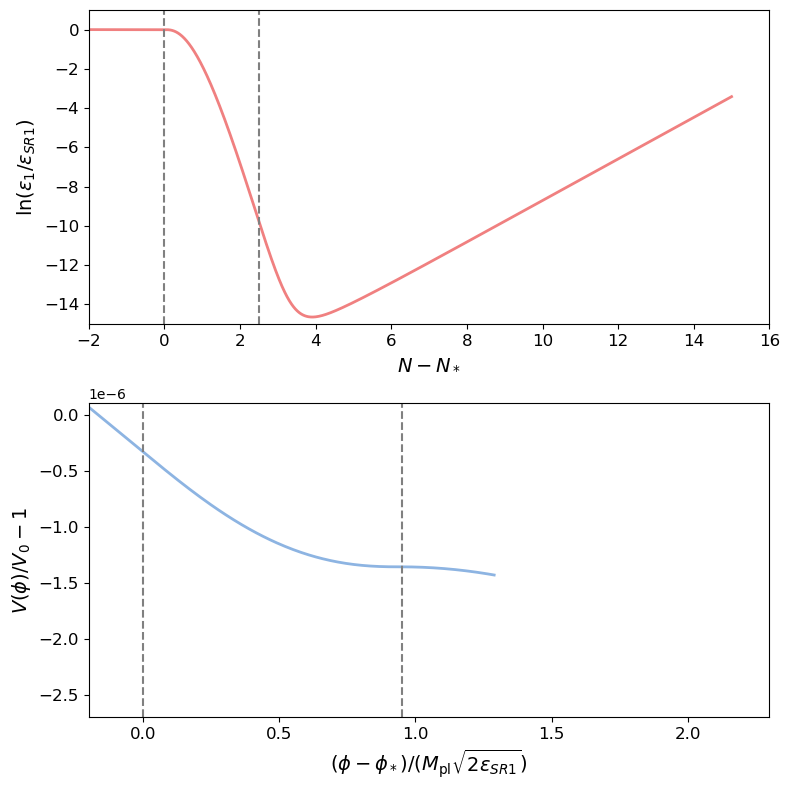

In [ ]:
eps_sr1 = 1e-6
M_pl = 1.0

# Top panel data
N_plot = model.N_grid
y_top = np.log(model.eps1_grid / eps_sr1)

# Bottom panel data
V0_paper = 3.0 * model.v0 # as V approx H^2(3 - eps1)
x_bot = model.phi_grid / (M_pl * np.sqrt(2 * eps_sr1))
y_bot = model.V_grid / V0_paper - 1.0

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=False)

# Panel 1
ax1.plot(N_plot, y_top, color='lightcoral', linewidth=2)
ax1.set_xlim(-2, 16)
ax1.set_ylim(-15, 1)
ax1.set_xlabel(r'$N - N_*$', fontsize=14)
ax1.set_ylabel(r'$\ln (\epsilon_1 / \epsilon_{SR1})$', fontsize=14)
ax1.axvline(0, color='gray', linestyle='--')
ax1.axvline(2.5, color='gray', linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=12)

# Panel 2
ax2.plot(x_bot, y_bot, color='#8DB4E2', linewidth=2)
ax2.set_xlim(-0.2, 2.3)
ax2.set_ylim(-2.7e-6, 0.1e-6)

ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax2.set_xlabel(r'$(\phi - \phi_*) / (M_{\rm{pl}} \sqrt{2\epsilon_{SR1}})$', fontsize=14)
ax2.set_ylabel(r'$V(\phi) / V_0 - 1$', fontsize=14)
ax2.axvline(0, color='gray', linestyle='--')
ax2.axvline(0.95, color='gray', linestyle='--') # matching vertical line for eps2=-6 roughly
ax2.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.show()
